<a href="https://colab.research.google.com/github/vasilisazhuk/math-statistics/blob/main/Mathstatistics_course_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TypeError: list indices must be integers or slices, not tuple

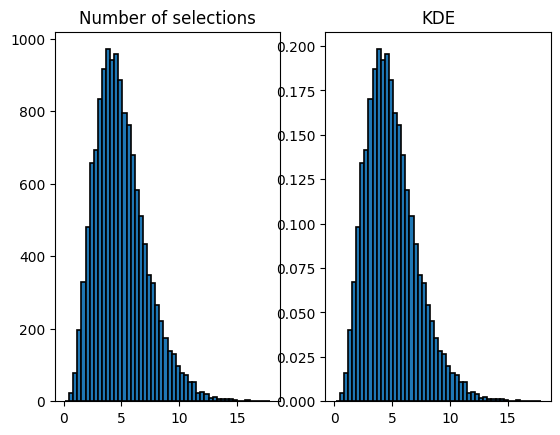

In [ ]:
import random
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.special import comb
from sklearn.neighbors import KernelDensity


def random_color():
    r = random.randint
    # exclude white
    return '#%02X%02X%02X' % (r(0, 200), r(0, 200), r(0, 200))


# 1.1
with open('/content/Task_2a_transposed.txt') as file:
    N = 13820
    values = []
    for line in file:
      values.append(float(line.rstrip()))

parts = 10
np.random.shuffle(values)
selections = np.array_split(np.copy(values), parts)
m = 50

step_function = np.zeros(m)
values_step = (max(values) + 0.001 * max(values) - min(values)) / m
columns_values = []
for t in range(1, m + 1):
    columns_values.append(min(values) + t * values_step)
for selection in selections + [values]:
    selection.sort()


linespace = np.linspace(values[0], values[-1], 100, dtype=float)
colors = [random_color() for _ in range(parts)]

def hist_prob(sample, plot, density=True, **kwargs):
    kwargs['edgecolor'] = kwargs.get('edgecolor', 'k')
    kwargs['linewidth'] = kwargs.get('linewidth', 1.2)

    plot.hist(sample, 50, density=density, **kwargs)


def kde(sample, x, kernel='gaussian', bandwidth=0.15) -> np.ndarray:
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth)
    kde.fit(sample[:, np.newaxis])
    log_pdf = kde.score_samples(x[:, np.newaxis])
    return np.exp(log_pdf)


def kde_prob(sample, plot, kernel='gaussian', bandwidth=0.15, **kwargs):
    kwargs['label'] = kwargs.get('label', 'kde')
    density = kde(sample, linespace, kernel, bandwidth)
    plot.plot(linespace, density, **kwargs)


# 1.2.2
fig_2, chart = plt.subplots(1, 2)
chart = chart.reshape(2)

hist_prob(values, chart[0], density=False)
chart[0].set_title("Number of selections")

hist_prob(values, chart[1])
chart[1].set_title("KDE")
kde_prob(values, chart[1], kernel="tophat", bandwidth=0.4, label="Tophat kernel")
kde_prob(values, chart[1], kernel="linear", bandwidth=0.4, label="Triangular kernel")
kde_prob(values, chart[1], kernel="gaussian",
         bandwidth=0.4, label="Gauss kernel")
fig_2.legend()


def point_estimations(sample):
    data = {}
    data['mean'] = np.mean(sample)
    data['median'] = np.median(sample)
    data['middle'] = (max(sample, default= 1) + min(sample, default= 1)) / 2
    data['variance'] = np.var(sample, ddof=1)
    data['moment 3'] = stats.moment(sample, 3)
    data['moment 4'] = stats.moment(sample, 4)
    data['kurtosis'] = stats.kurtosis(sample)
    data['skewness'] = stats.skew(sample)
    return data


fig_3_1, chart = plt.subplots(4, 2)
fig_3_1.subplots_adjust(hspace=1, left=.07, bottom=.05, right=.85)
chart = chart.reshape(8)


def var_interval(sample, q):
    var = np.var(sample, ddof=1)
    n = len(sample)

    left = var * (n - 1) / stats.chi2.ppf((1 + q) / 2, n - 1)
    right = var * (n - 1) / stats.chi2.ppf((1 - q) / 2, n - 1)
    return np.array([left, right])


def mean_interval(sample, q):
    mean = np.mean(sample)
    std = np.std(sample, ddof=1)
    n = len(sample)

    x = std / sqrt(n) * stats.t.ppf(0.5 + q / 2, n - 1)
    return np.array([mean - x, mean + x])


for selection_index, selection in enumerate(selections):
    selection_info = point_estimations(selection)
    print(selection_info)
    for i, data in enumerate(selection_info.keys()):
        chart[i].set_title(data)
        chart[i].set_yticklabels([])

        # adds labels
        if i == 0:
            chart[i].scatter(selection_info[data], 0, color=colors[selection_index],
                             marker='+', s=35, label='Selection {0}'.format(selection_index + 1))
        else:
            chart[i].scatter(selection_info[data], 0,
                             color=colors[selection_index], marker='+', s=35)

main_selection_info = point_estimations(values)
print(main_selection_info)
for i, data in enumerate(main_selection_info):
    # adds labels
    if i == 0:
        chart[i].scatter(main_selection_info[data], 0,
                         color='r', marker='.', s=100, label='Main Selection')
    else:
        chart[i].scatter(main_selection_info[data], 0,
                         color='r', marker='.', s=100)
fig_3_1.legend()


fig_3_2, chart = plt.subplots(11)
fig_3_3, chart1 = plt.subplots(11)
fig_3_2.subplots_adjust(hspace=1, left=.07, bottom=.05, right=.85)
fig_3_3.subplots_adjust(hspace=1, left=.07, bottom=.05, right=.85)
chart1 = chart1.reshape(11)
chart = chart.reshape(11)



q = 0.8
p = .95

for selection_index, selection in enumerate(selections):
    mean = mean_interval(selection, q)
    print("Left: " + str(mean[0]) + " Right: " + str(mean[-1]))
    var = var_interval(selection, q)
    print("Left: " + str(var[0]) + " Right: " + str(var[-1]))
    chart[selection_index].fill_between(
        mean, 0, 1, color=colors[selection_index], alpha=0.8, label='Selection {0}'.format(selection_index + 1))
    chart1[selection_index].fill_between(
       var, 0, 1, color=colors[selection_index], alpha=0.8, label='Selection {0}'.format(selection_index + 1))


mean = mean_interval(values, q)
var = var_interval(values, q)
chart[10].fill_between(mean, 0, 1, color='r', alpha=0.8, label='Main Selection')
chart1[10].fill_between(var, 0, 1, color='r', alpha=0.8, label='Main Selection')
fig_3_2.legend()
fig_3_3.legend()

# 1.4
def equivalent_k(n):
    def get_sum(k):
        return sum(comb(n, m) * p ** m * (1 - p) ** (n - m)
                   for m in range(n - k, n + 1))

    k = 0
    while get_sum(k) < 1 - q:
        k += 1

    return k


def interval_plot(plot, l_q, l_p, r_p, r_q):
    plot.scatter(l_q, 0, color='r', marker='>')
    plot.scatter(l_p, 0, color='k', marker='>', s=40)
    plot.scatter(r_p, 0, color='k', marker='<', s=40)
    plot.scatter(r_q, 0, color='r', marker='<')


fig_4, chart = plt.subplots(1, 1)
chart.set_yticklabels([])
chart.set_title('Main selection')
k = equivalent_k(N)
print(k)
print(equivalent_k(13820))

if k % 2:
    k -= 1

left_q = values[k // 2]
right_q = values[N - k // 2]
left_q_zero = -values[N - k + 1]
right_q_zero = values[N - k + 1]
print(left_q, right_q)
print(left_q_zero, right_q_zero)
left_p = np.quantile(values, 0.5 - p / 2)
right_p = np.quantile(values, 0.5 + p / 2)
interval_plot(chart, left_q, left_p, right_p, right_q)
fig_4_2, chart1 = plt.subplots(1)
chart1.scatter(left_q_zero, 0, color='r', marker='>')
chart1.scatter(right_q_zero, 0, color='r', marker='<')
chart1.set_title("Main selection")

fig_5, chart = plt.subplots(5, 2)
fig_5.subplots_adjust(hspace=1, wspace=0.3)
chart = chart.reshape(10)

for i, selection in enumerate(selections):
    chart[i].set_title("Selection {0}".format(i + 1))
    chart[i].set_yticklabels([])
    mean = np.mean(selection)
    std = np.std(selection, ddof=1)
    k = 1.65
    left_p = np.quantile(selection, 0.5 - p / 2)
    right_p = np.quantile(selection, 0.5 + p / 2)
    interval_plot(chart[i], mean - k * std, left_p,
                  right_p, mean + k * std)

plt.show()

0.128292
17.859


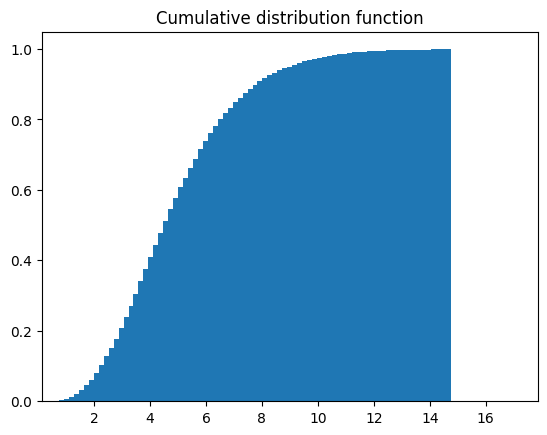

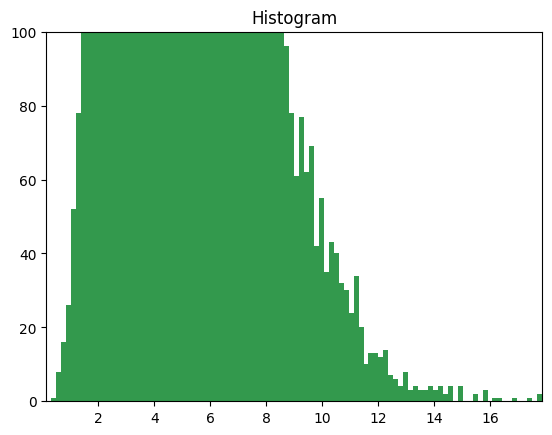

Histogram area:  1.0000000000000002


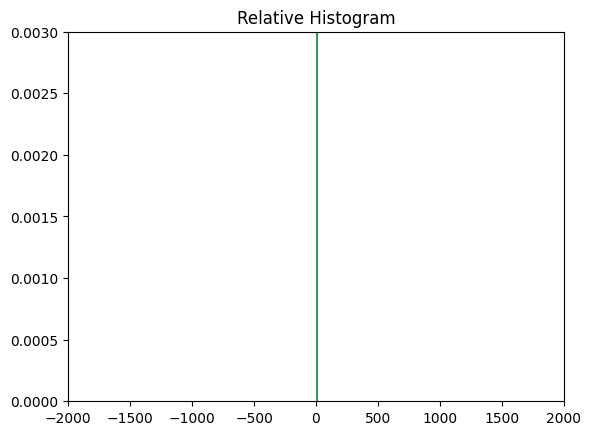

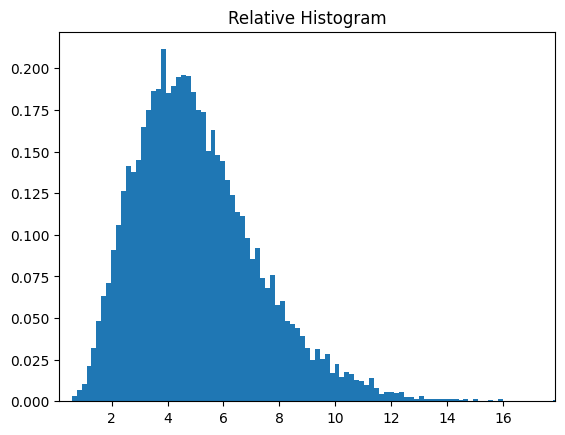

================== ТОЧЕЧНЫЕ ОЦЕНКИ =========================
	Min:  0.128292  Max:  17.859
	x_med : [4.6742, 4.579715, 4.691215, 4.693244999999999, 4.668275, 4.60019, 4.723459999999999, 4.762275, 4.649765, 4.758185, 4.56868]
	M[x] : [4.993342516028656, 5.022047426193922, 4.985020596237337, 5.00116134008683, 4.986399737337193, 4.963402388567294, 5.0248317018813315, 5.045461693198264, 4.897013039073806, 5.057099850217076, 4.950956717595945]
	x_ср : [8.993646, 8.1910395, 8.5084635, 9.294539, 9.257135000000002, 7.8085805, 7.810096, 8.9302955, 8.7134515, 8.190642, 7.5396945]
	s^2 : [4.9666681040810365, 4.984613662306387, 4.924982471760438, 4.917281118028913, 4.97486097413856, 4.765045047371142, 4.959051249692596, 5.103660963766713, 4.577667594488525, 5.231928191332878, 5.207017108997669]
	s : [2.2286022758852773, 2.232624836891856, 2.2192301529495397, 2.217494333257452, 2.2304396369636548, 2.182898313566425, 2.2268927342134366, 2.259128363720555, 2.139548455746802, 2.287340855957607, 2.2818

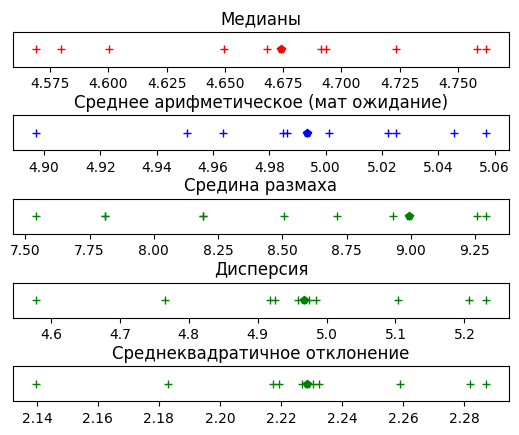

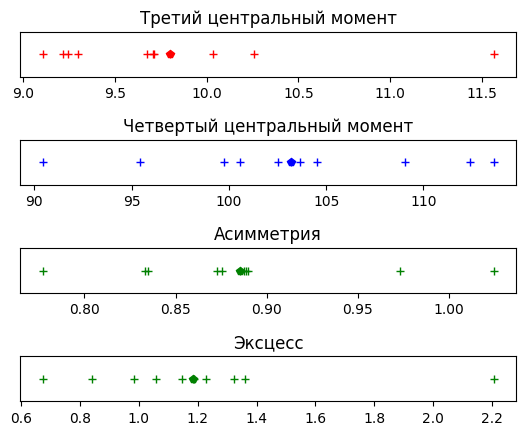

======================!!! Часть 1.4 . Интервальные оценки !!!===============


OverflowError: int too large to convert to float

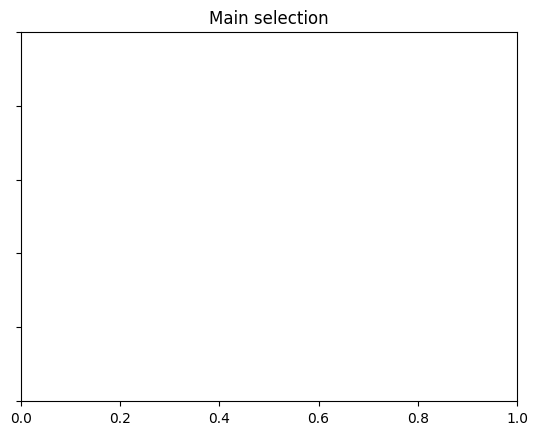

In [ ]:
import math
import matplotlib.pyplot as plot
import statistics as stat
import scipy.stats as stats
import numpy as np
import random
#import help
# https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html


# =================================== Подготовка данных(down) ===============================

relay_SDVIG = 0

f = open("Task_2a_transposed.txt", 'r')
line = f.readline().split(" ")
data = []
data2 = [[], [], [], [], [], [], [], [], [], []]
numOfPoints = 13819
numOfPointsInOneUnderArray = numOfPoints / 10

for line in f:
      data.append(float(line.rstrip()))


# создание 10 подвыборок
res = 0
random.shuffle(data)
for i in range(numOfPoints):
    j = int(i // numOfPointsInOneUnderArray)
    res += data[i]
    data2[j].append(data[i])

# сортировка значений
list.sort(data)
for l in data2:
    list.sort(l)
# ===========================  функция распределения и гистограммы =====================
m = 100  # кол-во интервалов
numbers = []
for number in data:
    if number < 50000:
        if number > -500000:
            numbers.append(number)
#
min_value = min(numbers)  # минимальное значение в выборке
max_value = max(numbers)  # максимальное значение в выборке
print(min_value)
distribution_fun = np.zeros(m)
print(max_value)
h = (max_value + 0.00000000001 * max_value - min_value) / m  # шаг, с которым идут интервалы
steps = []  # массив точек с шагом h
for t in range(1, m + 1):
    steps.append(t * h + min_value)

index = 0
for value in numbers:
 if value > steps[index]:
        p = int(abs(steps[index] - value) / h) + 1
        for i in range(1, p):
            distribution_fun[index + i] = distribution_fun[index]
        distribution_fun[index] = distribution_fun[index - 1]
        index += p
 distribution_fun[index - 1] += 1


plot.title("Cumulative distribution function")
plot.xlim([min(numbers), max(numbers)])  # CHANGE
plot.bar(steps, distribution_fun / len(numbers), h)
plot.show()
plot.title("Histogram")
plot.xlim([min(numbers), max(numbers)])  # CHANGE
plot.ylim((0,100))
plot.hist(numbers, steps, color=(0.2, 0.6, 0.3, 1.0))
plot.show()

# !!!!!!!!!Для относительной гистограммы
index = 0
for_relative = np.zeros(m)
steps = []  # массив точек с шагом h
for t in range(1, m + 1):
    steps.append(min_value + t * h)
for value in numbers:
    if value > steps[index]:
        p = int(abs(steps[index] - value) // h) + 1
        for_relative[index] = for_relative[index] / (h * len(numbers))
        index += p
    for_relative[index] += 1
for_relative[m - 1] = for_relative[m - 1] / (h * len(numbers))

# Проверка площади под гистограммой
ssss_____ = 0
for v in for_relative:
    ssss_____ += v * h
print('Histogram area: ', str(ssss_____))
# Конец проверки площади


plot.bar(steps, for_relative, width=h, color=(0.2, 0.6, 0.3, 1.0))
plot.title("Relative Histogram")
plot.xlim(-2000, 2000)  # CHANGE
plot.ylim(0,0.003)  # CHANGE
plot.show()

plot.bar(steps, for_relative, width=h)
plot.title("Relative Histogram")
plot.xlim([min(numbers), max(numbers)])  # CHANGE
plot.show()

# !!!!!!!!!!!!!!Относительная гистограмма построена

max_value = max(data)
# ================== ТОЧЕЧНЫЕ ОЦЕНКИ =========================
print("================== ТОЧЕЧНЫЕ ОЦЕНКИ =========================")
empty = np.zeros(11)
median = [stat.median(data)]  # медианы
mean = [stat.mean(data)]  # среднее арифметическое (мат. ожидание)
mid_range = [(min_value + max_value) / 2]  # средина размаха

dispersion = [np.var(data)]  # дисперсия s^2
root_of_dispersion = [math.sqrt(dispersion[0])]  # корень из дисперсии s
third_central_moment = [stats.moment(data, 3)]  # 3-ий центральный момент
fourth_central_moment = [stats.moment(data, 4)]  # 4-ый центральный момент
asymmetry = [stats.skew(data)]  # асимметрия
kurtosis = [stats.kurtosis(data)]  # эксцесс

interquantile_interval = [stats.iqr(data)]  # интерквантильный интервал

index = 1
for n in data2:
    median.append(stat.median(n))
    mean.append(stat.mean(n))
    mid_range.append((min(n) + max(n)) / 2)
    dispersion.append(np.var(n))
    root_of_dispersion.append((math.sqrt(dispersion[index])))
    third_central_moment.append(stats.moment(n, 3))
    fourth_central_moment.append(stats.moment(n, 4))
    asymmetry.append(stats.skew(n))
    kurtosis.append(stats.kurtosis(n))
    index += 1
print('\tMin: ', min_value, ' Max: ', max_value)
print('\tx_med :', median)
print('\tM[x] :', mean)
print('\tx_ср :', mid_range)
print('\ts^2 :', dispersion)
print('\ts :', root_of_dispersion)
print('\t∘µ_3 :', third_central_moment)
print('\t∘µ_4 :', fourth_central_moment)
print('\tAs :', asymmetry)
print('\tEx :', kurtosis)
#print('\tJ (номера значений) :', interquantile_interval)
#print('\tJ (значения) :', "(" + str(data[interquantile_interval[0]]) + ", " + str(data[interquantile_interval[1] - 1]) + ")")

# ==================== ГРАФИКИ ТОЧЕЧНЫХ ПОКАЗАТЕЛЕЙ =========================

plot.figure()

ax1 = plot.subplot(9, 1, 1)
ax1.set_ylim(-0.1, 0.1)
ax1.set_yticks([])
ax1.set_yticklabels([])
plot.title('Медианы')
plot.plot(median, empty, 'r+')
plot.plot(median[0], 0, 'rp')

ax2 = plot.subplot(9, 1, 3)
ax2.set_yticklabels([])
ax2.set_yticks([])
plot.title('Среднее арифметическое (мат ожидание)')
plot.plot(mean, empty, 'b+')
plot.plot(mean[0], 0, 'bp')

ax3 = plot.subplot(9, 1, 5)
ax3.set_yticks([])
ax3.set_yticklabels([])
plot.title('Средина размаха')
plot.plot(mid_range, empty, 'g+')
plot.plot(mid_range[0], 0, 'gp')

ax4 = plot.subplot(9, 1, 7)
ax4.set_yticks([])
ax4.set_yticklabels([])
plot.title('Дисперсия')
plot.plot(dispersion, empty, 'g+')
plot.plot(dispersion[0], 0, 'gp')

ax5 = plot.subplot(9, 1, 9)
ax5.set_yticks([])
ax5.set_yticklabels([])
plot.title('Среднеквадратичное отклонение')
plot.plot(root_of_dispersion, empty, 'g+')
plot.plot(root_of_dispersion[0], 0, 'gp')

plot.show()
plot.close()

plot.figure()
ax1 = plot.subplot(7, 1, 1)
ax1.set_ylim(-0.1, 0.1)
ax1.set_yticks([])
ax1.set_yticklabels([])
plot.title('Третий центральный момент')
plot.plot(third_central_moment, empty, 'r+')
plot.plot(third_central_moment[0], 0, 'rp')

ax2 = plot.subplot(7, 1, 3)
ax2.set_yticklabels([])
ax2.set_yticks([])
plot.title('Четвертый центральный момент')
plot.plot(fourth_central_moment, empty, 'b+')
plot.plot(fourth_central_moment[0], 0, 'bp')

ax3 = plot.subplot(7, 1, 5)
ax3.set_yticks([])
ax3.set_yticklabels([])
plot.title('Асимметрия')
plot.plot(asymmetry, empty, 'g+')
plot.plot(asymmetry[0], 0, 'gp')

ax4 = plot.subplot(7, 1, 7)
ax4.set_yticks([])
ax4.set_yticklabels([])
plot.title('Эксцесс')
plot.plot(kurtosis, empty, 'g+')
plot.plot(kurtosis[0], 0, 'gp')
plot.show()
plot.close()

# ==================== ГРАФИКИ ТОЧЕЧНЫХ ПОКАЗАТЕЛЕЙ НАЧЕРЧЕНЫ =================


# ======================!!! Часть 1.4 . Интервальные оценки !!!==================
print("======================!!! Часть 1.4 . Интервальные оценки !!!===============")
Q = 0.8  # доверительная вероятность
'''
left_chi2inv = stats.chi2.ppf(0.9, 14032.4775119351)  # посчитаны в MATLAB функцией chi2inv((1 + Q) / 2, n-1) CHANGE
right_chi2inv = stats.chi2.ppf(0.1, 13606.3789847199)  # посчитаны в MATLAB функцией chi2inv((1 - Q) / 2, n-1) CHANGE tinv = 1.2817  # посчитано в MATLAB функцией tinv(0.9, n-1), 0.9 = (1+q)/2, где q=0.8 CHANGE
tinv = 1.28161283090971
#mean_interval = [help.mean_interval(numOfPoints, mean[0], root_of_dispersion[0], tinv)]
#dispersion_interval = [help.dispersion_interval(numOfPoints, dispersion[0], left_chi2inv, right_chi2inv)]
mean_interval = [stats.t.interval(0.95, np.mean(data), 13819, stats.sem(data))]
dispersion_interval = [stats.t.interval(0.95, np.var(data), 13819, stats.sem(data))]
for i in range(1, 11):
    mean_interval.append(stats.t.interval(0.95, mean[i-1], 13819, stats.sem(data2[i-1])))
    dispersion_interval.append(stats.t.interval(0.95, dispersion[i-1], 13819, stats.sem(data2[i-1])))
print("\t Интервальные оценки для мат. ожидания" + str(mean_interval))
print("\t Интервальные оценки для дисперсии" + str(dispersion_interval))
# =================== Чертим ИНТЕРВАЛЬНЫЕ ОЦЕНКИ МАТ ОЖИДАНИЯ М ДИСПЕРСИИ ====================================

# Для мат. ожидания
plot.figure()
axes = [plot.subplot(11, 1, 1)]
axes[0].set_yticks([])
axes[0].set_ylabel('Full')
plot.title('Интервальные оценки мат. ожидания')
plot.setp(axes[0].get_xticklabels(), visible=False)
plot.plot(mean[0], 0, 'rp')
plot.plot(mean_interval[0][0], 0, 'b<')
plot.plot(mean_interval[0][1], 0, 'b>')

for i in range(1, 11):
    axes.append(plot.subplot(11, 1, i + 1, sharex=axes[0]))
    axes[i].set_yticks([])
    axes[i].set_ylabel(str(i))
    if i < 10: plot.setp(axes[i].get_xticklabels(), visible=False)
    plot.plot(mean[i], 0, 'r+')
    plot.plot(mean_interval[i][0], 0, 'b<')
    plot.plot(mean_interval[i][1], 0, 'b>')
mat_razmach = max(mean) - min(mean)
axes[0].set_xlim([min(mean) - 0.5 * mat_razmach, max(mean) + 0.5 * mat_razmach])  # CHANGE
plot.show()
plot.close()

# Для дисперсии

plot.figure()
axes = [plot.subplot(11, 1, 1)]
axes[0].set_yticks([])
axes[0].set_ylabel('Full')
plot.title('Интервальные оценки дисперсии')
plot.setp(axes[0].get_xticklabels(), visible=False)
plot.plot(dispersion[0], 0, 'rp')
plot.plot(dispersion_interval[0][0], 0, 'b<')
plot.plot(dispersion_interval[0][1], 0, 'b>')

for i in range(1, 11):
    axes.append(plot.subplot(11, 1, i + 1, sharex=axes[0]))
    axes[i].set_yticks([])
    axes[i].set_ylabel(str(i))
    if i < 10: plot.setp(axes[i].get_xticklabels(), visible=False)
    plot.plot(dispersion[i], 0, 'r+')
    plot.plot(dispersion_interval[i][0], 0, 'b<')
    plot.plot(dispersion_interval[i][1], 0, 'b>')
disp_razmach = max(dispersion) - min(dispersion)
axes[0].set_xlim([min(dispersion) - 0.5 * disp_razmach, max(dispersion) +0.5 * disp_razmach])
plot.show()
plot.close()
""""""
# =================== графики ИНТЕРВАЛЬНЫХ ОЦЕНКИ МАТ ОЖИДАНИЯ М ДИСПЕРСИИ напечатаны! ==========================


# ============================= ТОЛЕРАНТНЫЕ ПРЕДЕЛЫ ===================================

print("============================= ТОЛЕРАНТНЫЕ ПРЕДЕЛЫ ===================================")

p = 0.95  # вероятность для интерквантильного промежутка
q = 0.8  # доверительная вероятность
tolerant_interval_average = [0, 0]  # массив для толерантных пределов

k = help.find_k(numOfPoints, p, q)  # кол-во отбрасываемых точек
print("\tПредел k : " + str(k) + " , Значение биномиального распределения : " + str(
    stats.binom.cdf(numOfPoints - k, numOfPoints, p)))
# Для всей выборки относительно среднего арифметического
if k % 2 == 0:
    left_lim = int(k / 2)
    right_lim = int(numOfPoints - k / 2)
    tolerant_interval_average[0], tolerant_interval_average[1] = data[left_lim], data[right_lim]
else:
    left_lim = int((k - 1) / 2)
    right_lim = int(numOfPoints - (k - 1) / 2)
    tolerant_interval_average[0], tolerant_interval_average[1] = data[left_lim], data[right_lim]

# Для всей выборки относительно нуля
# Для этого возьмем модули отрицательных значений и пересортируем выборку
data_abs = np.sort(abs(np.array(data)))
tolerant_interval_zero = [-data_abs[numOfPoints - k + 1], data_abs[numOfPoints - k + 1]]
print("\tТолерантные пределы для всей выборки относительно среднего: " + str(tolerant_interval_average))
print("\tТолерантные пределы для всей выборки относительно нуля" + str(tolerant_interval_zero))

# ЧЕРТИМ

plot.title("Толерантные пределы для интерквантильного \nпромежутка относительно среднего значения")
plot.yticks([])
plot.plot(tolerant_interval_average[0], 0, 'b<')
plot.plot(tolerant_interval_average[1], 0, 'b>')
plot.plot(data[interquantile_interval[0]], 0, 'ro')
plot.plot(data[interquantile_interval[1]], 0, 'ro')
plot.legend(("Левый толерантный предел", "Правый толерантный предел", "Интерквантильный промежуток"), loc='upper right')
plot.show()
plot.close()

plot.title("Толерантные пределы относительно нуля")
plot.yticks([])
plot.plot(tolerant_interval_zero[0], 0, 'b<')
plot.plot(tolerant_interval_zero[1], 0, 'b>')
plot.legend(("Левый толерантный предел", "Правый толерантный предел"), loc='upper right')
plot.show()
plot.close()

# Считаем параметрические толерантные пределы подвыборок
k_tolerant_multiplier = 1.96
parametric_tolerant_interval = [[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]]
for i in range(10):
    parametric_tolerant_interval[i][0] = mean[i + 1] - k_tolerant_multiplier * root_of_dispersion[i + 1]
    parametric_tolerant_interval[i][1] = mean[i + 1] + k_tolerant_multiplier * root_of_dispersion[i + 1]
print("\tПараметрические толерантные интервалы для подвыборок:")
print("\t\t" + str(parametric_tolerant_interval))

axes = []
plot.title("Параметрические толерантные пределы для подвыборок")
for i in range(10):
    if i == 0:
        axes.append(plot.subplot(10, 1, i + 1))
    else:
        axes.append(plot.subplot(10, 1, i + 1, sharex=axes[0]))
    axes[i].set_yticks([])
    axes[i].set_ylabel(str(i + 1))
    if i < 9: plot.setp(axes[i].get_xticklabels(), visible=False)
    plot.plot(parametric_tolerant_interval[i][0], 0, 'b<')
    plot.plot(parametric_tolerant_interval[i][1], 0, 'b>')
    plot.plot(mean[i + 1], 0, 'ro')
plot.show()
plot.close()
'''

# 1.4
m = 50
N = 13819
p = 0.95
q = 0.8
values = data
def equivalent_k(n):
    def get_sum(k):
        return sum(math.comb(n, m) * p ** m * (1 - p) ** (n - m)
                   for m in range(n - k, n + 1))

    k = 0
    while get_sum(k) < 1 - q:
        k += 1

    return k


def interval_plot(plot, l_q, l_p, r_p, r_q):
    plot.scatter(l_q, 0, color='r', marker='>')
    plot.scatter(l_p, 0, color='k', marker='>', s=40)
    plot.scatter(r_p, 0, color='k', marker='<', s=40)
    plot.scatter(r_q, 0, color='r', marker='<')


fig_4, chart = plt.subplots(1, 1)
chart.set_yticklabels([])
chart.set_title('Main selection')
k = equivalent_k(N)
print(k)
print(equivalent_k(13820))

if k % 2:
    k -= 1

left_q = values[k // 2]
right_q = values[N - k // 2]
left_q_zero = -values[N - k + 1]
right_q_zero = values[N - k + 1]
print(left_q, right_q)
print(left_q_zero, right_q_zero)
left_p = np.quantile(values, 0.5 - p / 2)
right_p = np.quantile(values, 0.5 + p / 2)
interval_plot(chart, left_q, left_p, right_p, right_q)
fig_4_2, chart1 = plt.subplots(1)
chart1.scatter(left_q_zero, 0, color='r', marker='>')
chart1.scatter(right_q_zero, 0, color='r', marker='<')
chart1.set_title("Main selection")

fig_5, chart = plt.subplots(5, 2)
fig_5.subplots_adjust(hspace=1, wspace=0.3)
chart = chart.reshape(10)

for i, selection in enumerate(selections):
    chart[i].set_title("Selection {0}".format(i + 1))
    chart[i].set_yticklabels([])
    mean = np.mean(selection)
    std = np.std(selection, ddof=1)
    k = 1.65
    left_p = np.quantile(selection, 0.5 - p / 2)
    right_p = np.quantile(selection, 0.5 + p / 2)
    interval_plot(chart[i], mean - k * std, left_p,
                  right_p, mean + k * std)

plt.show()


AttributeError: Rectangle.set() got an unexpected keyword argument 'normed'

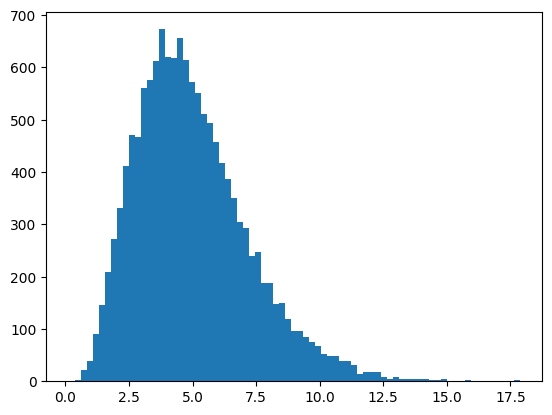

In [ ]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt


f = open("Task_2a_transposed.txt", 'r')
line = f.readline().split(" ")
data = []

for line in f:
      data.append(float(line.rstrip()))

x = np.linspace(min(data), max(data), 100)

plt.hist(data, bins="auto",normed=True)
plt.plot(x, mlab.normpdf(x, mean, sigma))

plt.show()

In [ ]:
!nvidia-smi

Thu May 30 04:30:36 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--